# Основы PyTorch и архитектуры нейросетей

**Цель**:
- освоить базовые операции с тензорами и механизмы автоматического дифференцирования;
- научиться создавать полносвязные, свёрточные и рекуррентные модели с использованием `torch.nn.Module`;
- понять общий пайплайн обучения: данные -> модель -> функция потерь -> оптимизатор -> цикл обучения.

Задание заточено на знакомство с библиотекой `pytorch` и навыками построения моделей глубинного обучения. И для его выполнения потребуется графический процессор.

`PyTorch` $-$ современная библиотека глубинного обучения, развивающаяся под крылом Facebook. Она не похожа на другие популярные библиотеки, такие как `Caffe`, `Theano` или `TensorFlow`. Она позволяет исследователям воплощать в жизнь свои самые смелые фантазии, а инженерам с лёгкостью эти фантазии имплементировать.

`PyTorch` немного похож на `numpy`: он тоже использует в своей основе массивы, которые называются `тензорами`. По сути, тензоры $-$ то же самое, что и `numpy.ndarray`, просто другой тип данных. Однако большинство операций, доступных для работы с тензорами, одинаково или почти похоже называются и в `pytorch`, и в `numpy`.

Почему же тогда исследователи (и мы вслед за ними) используют для нейронных сетей именно `torch`, а не `numpy`. В отличие от второго, `torch` позволяет запускать сложные матричные вычисления, лежащие в основе всех нейронных сетей, на графическом процессоре, а также легко считает градиенты.

Почему нужен графический процессор (`GPU`), а не обычный процессор? Дело в том, что матричные вычисления, кроме как в нейронных сетях, используются в графике компьютерных игр. Чтобы игры работалт быстрее, нужны эффективные способы считать матрицы и <strike>прямые руки программистов</strike> мощные видеокарты, которые эти вычисления обеспечивают. Развитие игровой индустрии привело к развитию графических процессоров, за что мы горячо благодарны всем геймерам мира.

Посмотрим, как использовать библиотеку по её прямому назначению. Здесь можете ознакомиться с <a href=https://pytorch.org/docs/stable/>документацией</a>.

## Блок 1. Основы PyTorch и автоградиент
### 1. Мастерство работы с тензорами
Тензор $-$ фундамент `PyTorch`. Важно понимать не только создание, но и управление памятью, размещение на устройствах и тонкости изменения формы.
#### 1.1 Базовые операции
Создайте тензоры:

In [1]:
import torch

# из списка
a = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32) # у торча есть своя система типов, обратите внимание
# тензор из случайных чисел
b = torch.randn(2, 2)
# тензор из единиц
c = torch.ones(2, 2)

Выполните поэлементное сложение, матричное умножение и измените форму тензора `a` в вектор (4 элемента).

In [2]:
a + b + c

tensor([[0.8776, 2.4997],
        [2.8281, 5.8503]])

In [3]:
a @ b @ c

tensor([[-2.2659, -2.2659],
        [-6.1545, -6.1545]])

In [4]:
torch.flatten(a)

tensor([1., 2., 3., 4.])

#### 1.2 Изменение формы и работа с памятью
Создайте тензор размером `(2, 3, 4)` из случайных чисел. Измените его форму на (3, 8) с помощью `.view()` и `.reshape()`. После этого измените исходный тензор `inplace` с помощью `.resize()`.

In [5]:
t = torch.rand(2,3,4)

In [6]:
t

tensor([[[0.5484, 0.0101, 0.8013, 0.2902],
         [0.3771, 0.9845, 0.0806, 0.8379],
         [0.6193, 0.5296, 0.0822, 0.4285]],

        [[0.8359, 0.9477, 0.2694, 0.6300],
         [0.6390, 0.2306, 0.3170, 0.7281],
         [0.6141, 0.4458, 0.5199, 0.7844]]])

In [7]:
t.view(3,8)

tensor([[0.5484, 0.0101, 0.8013, 0.2902, 0.3771, 0.9845, 0.0806, 0.8379],
        [0.6193, 0.5296, 0.0822, 0.4285, 0.8359, 0.9477, 0.2694, 0.6300],
        [0.6390, 0.2306, 0.3170, 0.7281, 0.6141, 0.4458, 0.5199, 0.7844]])

In [8]:
t.reshape(3,8)


tensor([[0.5484, 0.0101, 0.8013, 0.2902, 0.3771, 0.9845, 0.0806, 0.8379],
        [0.6193, 0.5296, 0.0822, 0.4285, 0.8359, 0.9477, 0.2694, 0.6300],
        [0.6390, 0.2306, 0.3170, 0.7281, 0.6141, 0.4458, 0.5199, 0.7844]])

In [9]:
t.resize(3, 8)

c:\Users\Aleggg\Documents\code\.venv\Lib\site-packages\torch\_tensor.py:1000: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


tensor([[0.5484, 0.0101, 0.8013, 0.2902, 0.3771, 0.9845, 0.0806, 0.8379],
        [0.6193, 0.5296, 0.0822, 0.4285, 0.8359, 0.9477, 0.2694, 0.6300],
        [0.6390, 0.2306, 0.3170, 0.7281, 0.6141, 0.4458, 0.5199, 0.7844]])


В каком случае `view()` вызовет ошибку,  а `reshape()` $-$ нет? Создайте несмежный тензор с помощью транспонирования и проверьте `.is_contiguous()`.

In [10]:
u = torch.rand(2,3,4)

In [11]:
u.is_contiguous()

True

In [12]:
ut = u.T
ut

C:\Temp\ipykernel_9060\3913076868.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3729.)
  ut = u.T


tensor([[[0.6976, 0.8014],
         [0.9903, 0.7848],
         [0.8132, 0.9203]],

        [[0.0805, 0.4344],
         [0.5590, 0.0491],
         [0.9173, 0.9865]],

        [[0.6380, 0.3691],
         [0.8325, 0.7120],
         [0.0026, 0.5631]],

        [[0.1864, 0.8654],
         [0.2946, 0.6139],
         [0.0372, 0.0229]]])

In [13]:
ut.is_contiguous()

False

In [14]:
u.view(3,8)

tensor([[0.6976, 0.0805, 0.6380, 0.1864, 0.9903, 0.5590, 0.8325, 0.2946],
        [0.8132, 0.9173, 0.0026, 0.0372, 0.8014, 0.4344, 0.3691, 0.8654],
        [0.7848, 0.0491, 0.7120, 0.6139, 0.9203, 0.9865, 0.5631, 0.0229]])

In [15]:
ut.view(3,8)

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [ ]:
u.reshape(3,8)

tensor([[0.0745, 0.4289, 0.3270, 0.5144, 0.0688, 0.1627, 0.1196, 0.3607],
        [0.9325, 0.5806, 0.9128, 0.4042, 0.7091, 0.2539, 0.3297, 0.3846],
        [0.4419, 0.9838, 0.8194, 0.8553, 0.7785, 0.4435, 0.8574, 0.4835]])

In [ ]:
ut.reshape(3,8)

tensor([[0.0745, 0.7091, 0.0688, 0.4419, 0.9325, 0.7785, 0.4289, 0.2539],
        [0.1627, 0.9838, 0.5806, 0.4435, 0.3270, 0.3297, 0.1196, 0.8194],
        [0.9128, 0.8574, 0.5144, 0.3846, 0.3607, 0.8553, 0.4042, 0.4835]])

view на смежные, reshape копирует но влияет на память

#### 1.3 Broadcasting и умные операции
Даны два тензора: `x` размером `(5, 1)` и `y` размером `(1, 4)`. Получите результа `x + y` и объясните, как работает broadcasting.

In [ ]:
x = torch.rand(5,1)
y = torch.rand(1,4)

In [ ]:
x + y

tensor([[0.6793, 0.4916, 1.2346, 1.4048],
        [0.3629, 0.1752, 0.9182, 1.0885],
        [0.4171, 0.2294, 0.9724, 1.1426],
        [0.4312, 0.2436, 0.9866, 1.1568],
        [1.0305, 0.8428, 1.5858, 1.7560]])

расширение тензора до нужного размера но при условии что хотя бы 1 размерость будет одинаковая

#### 1.4 Перемещение данных между CPU и GPU

In [2]:
# проверьте доступность CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
# создайте тензор на CPU и перенесите на GPU 
your_cpu_tensor = torch.rand(1000, 1000)
your_cpu_tensor.to(device)

tensor([[0.2892, 0.1188, 0.0432,  ..., 0.1317, 0.4925, 0.7365],
        [0.4033, 0.3314, 0.4218,  ..., 0.6624, 0.3623, 0.4907],
        [0.2496, 0.1129, 0.6183,  ..., 0.7483, 0.6916, 0.2431],
        ...,
        [0.5624, 0.1871, 0.8679,  ..., 0.3668, 0.1410, 0.0582],
        [0.7237, 0.7866, 0.7421,  ..., 0.9668, 0.7098, 0.0573],
        [0.5491, 0.8228, 0.8399,  ..., 0.6075, 0.2423, 0.2131]])

In [ ]:
# выполните матричное умножение на GPU и замерьте время
import time
start = time.time()
result = your_cpu_tensor @ your_cpu_tensor# матричное умножение
torch.cuda.synchronize() # дождаться завершения GPU операций
print(f"Время на GPU: {time.time() - start:.4f} сек")

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# сравните с CPU, есть ли разница

# у меня отсутсует поддержка cuda ядра((((

### 2. Autograd $-$ автоматическое дифференцирование
Автоматическое дифференцирование $-$ сердце `PyTorch`. Важно уметь управлять графом вычислений.
#### 2.1 Вычисление градиентов для произвольной функции
Найдите градиент функции $$ f(x, y) = x^3 + 3xy^2$$ в точке `(2,3)`, используя метод `backward()`

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

j = x**3 + 3*x*y**2
j.backward()

print(f"df/dx = {x.grad}")  # ожидаем 3*4 + 3*9 = 12+27=39
print(f"df/dy = {y.grad}")  # ожидаем 6*x*y = 36

df/dx = 39.0
df/dy = 36.0


Теперь сбросим градиенты:

In [ ]:
x.grad.zero_()
y.grad.zero_()

tensor(0.)

Вычислите вторую производную $\frac{\mathrm{d}^2 f}{\mathrm{d} x^2}$ с помощью `create_graph=True`:

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

j = x**3 + 3*x*y**2
j.backward(create_graph=True)

f1 = x.grad
f2 = y.grad

f1.backward()
f2.backward()

x.grad,y.grad

c:\Users\Aleggg\Documents\code\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\engine.cpp:1304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


(tensor(69., grad_fn=<CopyBackwards>), tensor(66., grad_fn=<CopyBackwards>))

#### 2.2 Функции `detach` и `no_grad`

Дана модель с одним линейным слоем:

In [ ]:
lin = torch.nn.Linear(10, 1)

# генерация входных данных
x = torch.randn(5, 10, requires_grad=True)
out = lin(x).sum()
out.backward()
out

tensor(-0.8759, grad_fn=<SumBackward0>)

Теперь мы хотим использовать выход модели для чего-то ещё, но не хотим, чтобы градиенты текли обратно в модель. Как это сделать?

In [ ]:
lin = torch.nn.Linear(10, 1)

# генерация входных данных
x = torch.randn(5, 10, requires_grad=True)

with torch.no_grad():
    out = lin(x)
out = out.sum()
out

tensor(2.3742)

In [ ]:
lin = torch.nn.Linear(10, 1)

# генерация входных данных
y = torch.randn(5, 10, requires_grad=True).detach()

out = lin(y).sum()
out.backward()
out

tensor(2.1761, grad_fn=<SumBackward0>)

#### 2.3 Визуализация графа вычислений
Установите `torchviz` и `graphviz`.

In [ ]:
from torchviz import make_dot

x = torch.randn(1, 10, requires_grad=True)
y = torch.nn.Linear(10, 5)(x)
y = torch.relu(y)
z = torch.nn.Linear(5, 1)(y)

make_dot(z)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

выдает ошибку почему то но на google colab ее нет

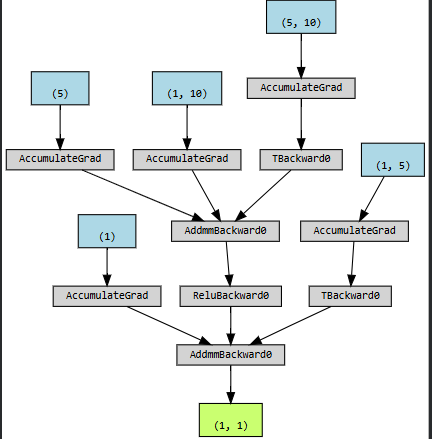

### 3. Углублённая работа с `nn.Module`

Понимание внутреннего устройства модулей необходимо для создания сложных архитектур.

#### 3.1 Кастомный слой с обучаемыми параметрами
Создайте слой, реализующий операцию `y = A * x + b`, где `A` $-$ диагональная матрица, а `b` $-$ вектор. Поясню: вам необходимо создать класс (пусть будет `DiagonalLinear`), наследующий классу `torch.nn.Module`. Параметры слоя должны обучаться и должны быть зарегистрированы через `nn.Parameter`.

In [3]:
import torch.nn as nn

In [4]:
class DiagonalLinear(nn.Module):
    def __init__(self, feat):
        super(DiagonalLinear, self).__init__()
        self.feat = feat

        self.A_ = nn.Parameter(torch.randn(feat) * 0.1)
        self.b_ = nn.Parameter(torch.zeros(feat))


    def forward(self, x):
        y = self.A_ * x + self.b_

        return y

In [ ]:
model = DiagonalLinear(feat=5)
x = torch.randn(3, 5)
model(x)

tensor([[-0.0524,  0.0106, -0.0497, -0.0033,  0.0162],
        [-0.0998, -0.0053,  0.1167, -0.0054,  0.1009],
        [-0.1222, -0.0029, -0.0290, -0.0006, -0.0149]], grad_fn=<AddBackward0>)

#### 3.2 Регистрация буферов (необучаемых тензоров)
Добавьте в свой слой скользящее среднее активаций (running mean), которое обновляется во время выполнения метода `forward`, но не участвует в градиентном спуске.

Формула скользящего среднего: $$\mu_{running} = (1 - momentum) * \mu_{running} + \mu_{batch} * momentum$$

In [5]:
class LayerWithStats(nn.Module):#я исправил класс для будущего задания
    def __init__(self, feat, momentum=0.1):
        super(LayerWithStats, self).__init__()
        self.momentum = momentum
        self.register_buffer('running_mean', torch.zeros(feat))

    def forward(self, x):
        self.running_mean  = (1 - self.momentum) * self.running_mean + torch.mean(x, dim=0) * self.momentum

        return x

In [17]:
model1 = LayerWithStats(feat=5)
x1 = torch.randn(3, 5)
model1(x1)

tensor([[ 0.0058, -0.0195, -0.1351,  0.0655, -0.1154],
        [ 0.0160, -0.0434,  0.0162, -0.0740,  0.1112],
        [ 0.0280,  0.0114, -0.0136, -0.0351, -0.0687]], grad_fn=<AddBackward0>)

#### 3.3 Инициализация весов
Напишите функцию, которая инициализирует веса линейных слоёв по Ксавье, а свёрточных $-$ по Каймингу.


In [ ]:
def init(mol):
    if isinstance(mol, nn.Linear):
        nn.init.xavier_uniform_(mol.weight)
        nn.init.zeros_(mol.bias)
    elif isinstance(mol, (nn.Conv2d)):
        nn.init.kaiming_uniform_(mol.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(mol.bias)

## Блок 2. Разработка полносвязной нейронной сети на PyTorch
**Какая цель**: создать полноценный пайплайн обучения классификатора изображений на 10 классов с использованием только полносвязных слоёв, освоив при этом ключевые возможности PyTorch: от управления данными и кастомных компонентов до профилирования и экспорта модели.

**Данные**: <a href=https://www.kaggle.com/datasets/alessiocorrado99/animals10>Animals-10</a>

**Описание**:
- Около 28 000 цветных изображений среднего качества;
- 10 классов: `dog`, `cat`, `horse`, `spyder`, `butterfly`, `chicken`, `sheep`, `cow`, `squirrel`, `elephant`;
- Количество изображений в каждом классе варьируется от 2 000 до 5 000 (несбалансированный набор);
- Присутствует некоторый шум (ошибочные изображения), что приближает задачу к реальным условиям;
- Данные организованы по папкам: корневая папка `raw-img/`, внутри подпапки с именами классов.

**Что делать**: 
- необходимо привести все изображения к одному размеру (например, $64\times64$);
- для уменьшения числа параметров можно конвертировать в градации серого (1 канал), тогда входной слой: $64\times64 = 4096$ нейронов;
- так как классов 10, выходной слой будет иметь 10 нейронов, функция потери $-$ `CrossEntropyLoss`;
- учитывая несбалансированность классов, желательно вычислять взвешенную точность (`accuracy`) или использовать веса классов в функции потерь.

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Aleggg\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2


In [7]:
path = path + "\\raw-img\\"

In [8]:
path

'C:\\Users\\Aleggg\\.cache\\kagglehub\\datasets\\alessiocorrado99\\animals10\\versions\\2\\raw-img\\'

### Этап 1. Настройка окружения и загрузка данных с кастомным `Dataset`

1. Установите библиотеки `torch`, `torchvision`, `pillow\openCV`, `matplotlib`, `tqdm`, `torchviz`.
2. Создайте класс `AnimalDataset`, унаследованный от `torch.utils.data.Dataset`:
    - в конструкторе принимает путь к корневой папке с подпапками классов и флаг `train` (для разделения `train/val`);
    - сканирует папки, собирает пути ко всем изображениям и соответствующие метки (целые числа от 0 до 9);
    - создаёт словарь `class_to_idx` для отображения имени папки в индекс;
    - применяет аугментации только для обучающей выборки (например, случайное горизонтальное отражение, поворот, изменение яркости). Для валидации $-$ только ресайз, преобразование в тензор и нормализация;
    - реализует метод `__len__` и `__getitem__`. 

In [9]:
from torch.utils.data import Dataset
import os
from PIL import Image
import random
from torchvision import transforms


class AnimalDataset(Dataset):
    def __init__(self, dir, train = True, split=0.7, seed=42):
        self.dir = dir
        self.train = train
        self.split = split


        classes = os.listdir(dir)
        self.class_to_idx = {classes_name: idx for idx, classes_name in enumerate(classes)}

        self.samples = []
        for class_name in classes:
            class_dir = os.path.join(dir, class_name)

            for img_name in os.listdir(class_dir):
                item_path = os.path.join(class_dir, img_name)

                if os.path.isfile(item_path) and item_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((item_path, self.class_to_idx[class_name]))

        # Разделение на train и test
        random.seed(seed)
        random.shuffle(self.samples)
        split_idx = int(len(self.samples) * split)
        if train:
            self.samples = self.samples[:split_idx]
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2),
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # там морака с нормализацией, так что я добавил из imageNet
            ])

        else:
            self.samples = self.samples[split_idx:]
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])# там морака с нормализацией, так что я добавил из imageNet
            ])
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        return image, label
    

3. Определите трансформации:
    - обучающая выборка: ресайз до $64\times64$, конвертация в градации серого, случайные аугментации, преобразование в тензор, нормализация;
    - валидационная: только ресайз, градации серого, тензор, нормализация

Для этого почитайте документацию к `torchvision.transforms`.

In [10]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device # ладно, у меня было cuda просто разобрался с драйверами

device(type='cuda')

In [11]:
train_dataset = AnimalDataset(dir=path, train=True, seed = 17)
test_dataset = AnimalDataset(dir=path, train=False, seed = 17)


# нормализовывать и "случайные аугментации" не буду, т к уже выполнял в классе
train_dataset.transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
    ])

test_dataset.transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
    ])

In [12]:
image, label = train_dataset[0]
image.shape

torch.Size([1, 64, 64])

In [13]:
image, label = test_dataset[0]
image.shape

torch.Size([1, 64, 64])

In [14]:
os.cpu_count()

8

4. Создайте `DataLoader` с `batch_size=64` (или 128, тоже можно).

In [15]:
from torch.utils.data import DataLoader 

train_dataset_loader = DataLoader(train_dataset, batch_size = 64, shuffle=True, pin_memory=True)
test_dataset_loader = DataLoader(test_dataset, batch_size = 64, shuffle=False, pin_memory=True)

In [16]:
image, label = next(iter(train_dataset_loader))
image.shape

torch.Size([64, 1, 64, 64])

### Этап 2. Создание модели с использованием продвинутых возможностей `nn.Module`
Разработайте класс `AnimalFC` $-$ глубокая полносвязная сеть для классификации 10 видов.

**Предлагаемая архитектура**:
- вход: 4096 ($64\times64\times1$);
- скрытые слои: 2048 --> 1024 --> 512 --> 256 --> 128;
- после каждого скрытого слоя: `BatchNorm1d` + `ReLU` + `Dropout(0.3)`;
- выходной слой: 10 нейронов (без активации, так как используется `CrossEntropyLoss`).

In [17]:
class AnimalFC(nn.Module):
    def __init__(self, drop_out = 0.3):
        super(AnimalFC, self).__init__()

        self.feat = nn.Sequential(
            nn.Linear(4096, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_out),
            
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_out),
            LayerWithStats(1024),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_out),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_out),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_out),

            DiagonalLinear(128)
        )

        self.classes = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.feat(x)
        x = self.classes(x)
        
        return x
        


**Дальше**:
- замените один из линейных слоёв на ваш кастомный слой `DiagonalLinear`, чтобы продемонстрировать создание слоя с обучаемой диагональной матрицей;
- вставьте слой `LayerWithStats`, который отслеживает скользящее среднее активаций после определённого слоя. Это полезно для мониторинга распределений во время обучения.

### Обучение модели с кастомными компонентами
#### 3.1 Функция потерь
- основная: `nn.CrossEntropyLoss`;
- учитывая несбалансированность классов, можно вычислить веса классов и передать их в `CrossEntropyLoss(weight=class_weights)`.

#### 3.2 Оптимизатор и планировщик
- оптимизатор: `torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)`;
- планировщик: `ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)`.

#### 3.3 Цикл обучения
Реализуйте функции `train_epoch` и `validate`:
- в `train_epoch`: модель в режим `model.train()`, для каждого батча $-$ прямой проход, вычисление `loss`, `backward()`, `optimizer.step()`, `optimizer.zero_grad()`;
- в `validate`: модель в режим `model.eval()`, с `torch.no_grad()` вычисляются `loss` и `accuracy`;
- отслеживайте точность (accuracy) для мультиклассовой классификации: `(preds.argmax(dim=1) == labels).float().mean()`;
- сохраняйте `state_dict` модели с наилучшей валидационной точностью.

In [19]:
model = AnimalFC().to(device)

In [20]:
model

AnimalFC(
  (feat): Sequential(
    (0): Linear(in_features=4096, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): LayerWithStats()
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=512, out_features=256, bias=True)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU(inplace=True)
    (16): Dropout(p=0.3, inplace=False)
    (17): Linear(in_features=256, out_features=128, 

In [21]:
from collections import Counter

#3.1
def compute_class_weights(dataset):
    labels = [label for _, label in dataset]
    counts = Counter(labels)
    total = len(labels)
    n_classes = len(counts)
    weights = [total / (n_classes * counts[i]) for i in range(n_classes)]
    return torch.tensor(weights, dtype=torch.float32).to(device)

class_weights = compute_class_weights(train_dataset)
criterion = nn.CrossEntropyLoss(weight=class_weights)

#3.2
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [22]:
#3.3
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [23]:
model.to(device)

AnimalFC(
  (feat): Sequential(
    (0): Linear(in_features=4096, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): LayerWithStats()
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=512, out_features=256, bias=True)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU(inplace=True)
    (16): Dropout(p=0.3, inplace=False)
    (17): Linear(in_features=256, out_features=128, 

In [24]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
num_epochs = 17

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_dataset_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_dataset_loader, criterion, device)
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}: '
          f'train Loss: {train_loss:.4f}, train Acc: {train_acc:.2f}% | '
          f'test Loss: {val_loss:.4f}, test Acc: {val_acc:.2f}%')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f'New best model saved (acc: {val_acc:.2f}%)')

Epoch 1/17: train Loss: 2.2051, train Acc: 18.47% | test Loss: 2.1482, test Acc: 18.18%
New best model saved (acc: 18.18%)
Epoch 2/17: train Loss: 2.0706, train Acc: 24.55% | test Loss: 2.0388, test Acc: 25.83%
New best model saved (acc: 25.83%)
Epoch 3/17: train Loss: 1.9943, train Acc: 27.09% | test Loss: 2.0437, test Acc: 25.30%
Epoch 4/17: train Loss: 1.9415, train Acc: 29.77% | test Loss: 2.0013, test Acc: 27.57%
New best model saved (acc: 27.57%)
Epoch 5/17: train Loss: 1.8875, train Acc: 31.31% | test Loss: 2.0097, test Acc: 22.42%
Epoch 6/17: train Loss: 1.8437, train Acc: 32.65% | test Loss: 1.9701, test Acc: 28.75%
New best model saved (acc: 28.75%)
Epoch 7/17: train Loss: 1.7876, train Acc: 34.54% | test Loss: 1.9954, test Acc: 25.44%
Epoch 8/17: train Loss: 1.7348, train Acc: 36.32% | test Loss: 2.0533, test Acc: 29.27%
New best model saved (acc: 29.27%)
Epoch 9/17: train Loss: 1.6820, train Acc: 38.26% | test Loss: 2.0645, test Acc: 24.04%
Epoch 10/17: train Loss: 1.6256, 

### Этап 4. Анализ и профилирование
1. Запустите профилировщик для одного батча, чтобы определить узкие места:

In [27]:
inputs, labels = next(iter(train_dataset_loader))
inputs, labels = inputs.cuda(), labels.cuda()

with torch.autograd.profiler.profile(use_cuda=True) as prof:
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
autograd::engine::evaluate_function: torch::autograd...         4.91%     446.300us        16.22%       1.475ms      61.467us     648.000us         1.14%      24.226ms       1.009ms            24  
                        torch::autograd::AccumulateGrad         6.20%     564.200us        11.31%       1.029ms      42.871us     336.000us         0.59%      23.578ms     982.417us            24  
         

C:\Temp\ipykernel_7580\3474435063.py:4: FutureWarning: The attribute `use_cuda` will be deprecated soon, please use ``use_device = 'cuda'`` instead.
  with torch.autograd.profiler.profile(use_cuda=True) as prof:


Ожидается, что основные затраты времени придутся на матричные умножения в линейных слоях.

2. Для `DiagonalLinear` выполните `torch.autograd.gradcheck`:

In [28]:
from torch.autograd import gradcheck
layer = DiagonalLinear(5).double()
input_tensor = torch.randn(3, 5, requires_grad=True, dtype=torch.double)
test = gradcheck(layer, input_tensor, eps=1e-6, atol=1e-4)
print("Gradient check passed:", test)

Gradient check passed: True


3. **Визуализация обучения**:
    - построить график `loss` на train и val по эпохам;
    - построить график `accuracy` на train и val по эпохам;
    - построить график `learning_rate` по эпохам.

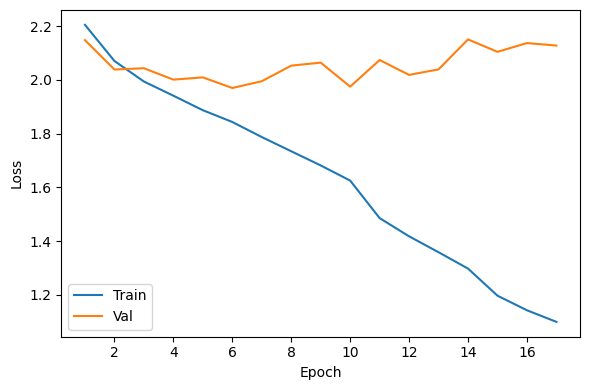

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, label='Train')
plt.plot(epochs, val_losses, label='Test')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

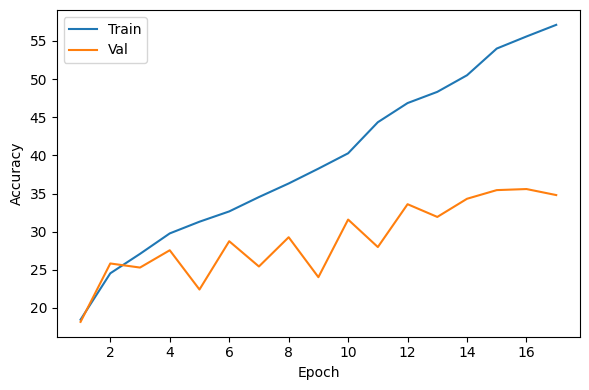

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, label='Train')
plt.plot(epochs, val_accs, label='Test')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# я не собирал((((